In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
sparc_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC/sparc_ALL.csv')

Chosen_gals_TNG = np.loadtxt('/mnt/users/darnej/MPhys/TNG-50/Chosen_galaxies_final_TNG.txt')

Chosen_gals_NH = np.loadtxt('/mnt/users/darnej/MPhys/Chosen_galaxies_final_NH.txt')

gals_dataframe_TNG = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

gals_dataframe_NH = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')

sparc_df = pd.DataFrame(sparc_csv)

print(list(sparc_df.columns.values))

sparc_df.head()

#VARIABLES TO COMPARE:

# masses
# Ratio
# Gas ratio
# r_half 
# r_half_gas


['Name', 'Unnamed: 0', 'level_0', 'index', 'T', 'D', 'e_D', 'f_D', 'Inc', 'e_Inc', 'L[3.6]', 'e_L[3.6]', 'Reff', 'SBeff', 'Rdisk', 'SBdisk', 'MHI', 'RHI', 'Vflat', 'e_Vflat', 'Q', 'References', 'log(Mb)', 'e_log(Mb)', 'Vf', 'e_Vf', 'V2exp', 'e_V2exp', 'V2eff', 'e_V2eff', 'Vmax', 'e_Vmax', 'Wp20', 'e_Wp20', 'Wm50', 'e_Wm50', 'Wm50c', 'e_Wm50c', 'Lbul', 'mgas', 'mbar', 'ra', 'dec', 'ipac_z', 'num_data', 'max_rad', 'am', 'kin_nfw_full_z', 'kin_nfw_full_zerr', 'kin_nfw_full_loglike', 'kin_nfw_full_modes', 'kin_nfw_full_mass', 'kin_nfw_full_mass_lower', 'kin_nfw_full_mass_upper', 'kin_nfw_full_mass_sig', 'kin_nfw_full_mass_med', 'kin_nfw_full_conc', 'kin_nfw_full_conc_lower', 'kin_nfw_full_conc_upper', 'kin_nfw_full_conc_sig', 'kin_nfw_full_conc_med', 'kin_nfw_full_Ydisk', 'kin_nfw_full_Ydisk_lower', 'kin_nfw_full_Ydisk_upper', 'kin_nfw_full_Ydisk_sig', 'kin_nfw_full_Ydisk_med', 'kin_nfw_full_Inc', 'kin_nfw_full_Inc_lower', 'kin_nfw_full_Inc_upper', 'kin_nfw_full_Inc_sig', 'kin_nfw_full_Inc

,Name,Unnamed: 0,level_0,index,T,D,e_D,f_D,Inc,e_Inc,...,alf_siglogMH,xnsa_xalf,SERSIC_ABSMAG_R,SERSIC_AMIVAR_R,AGCNr,alf_HIcode,hires,Lyle_table1,Lyle_table2,Lyle_spectra
0,CamB,0,0.0,0.0,10.0,3.36,0.26,2.0,65.0,5.0,...,NaN,0,NaN,NaN,-1,NaN,1.0,0.0,0.0,0.0
1,D512-2,1,1.0,1.0,10.0,15.20,4.56,1.0,56.0,10.0,...,0.15,0,NaN,NaN,242165,1.0,0.0,0.0,0.0,0.0
2,D564-8,2,2.0,2.0,10.0,8.79,0.28,2.0,63.0,7.0,...,0.09,1,-13.480411,548.214661,191794,NaN,0.0,0.0,0.0,0.0
3,D631-7,3,3.0,3.0,10.0,7.72,0.18,2.0,59.0,3.0,...,0.09,0,NaN,NaN,4115,1.0,0.0,1.0,1.0,1.0
4,DDO064,4,4.0,4.0,10.0,6.80,2.04,1.0,60.0,5.0,...,0.10,0,NaN,NaN,5272,1.0,1.0,1.0,0.0,0.0


In [3]:
#logM* =  log10(0.5 * 1e9 * L[3.6] + 0.7 * 1e9 * Lbul )
# 0.5 is the mass-to-light ratio of the stellar disk in the 3.6 micron band
# 0.7 is the mass-to-light ratio of the stellar bulge

L_3_6 = sparc_df['L[3.6]']  # Convert from solar luminosities to physical units
L_bul = sparc_df['Lbul']  # Convert from solar luminosities to physical units
Reff = sparc_df['Reff']  # Effective radius in kpc
RHI = sparc_df['RHI']  # HI radius in kpc
Vflat = sparc_df['Vflat']  # Flat rotation velocity in km/s
max_rad_sparc = sparc_df['max_rad']  # Maximum radius in kpc


sparc_mass_matched_indices = np.loadtxt('/mnt/users/darnej/MPhys/SPARC/mass_matched_indices.txt', dtype=int)
print(sparc_mass_matched_indices)


L_3_6 = L_3_6[sparc_mass_matched_indices]
L_bul = L_bul[sparc_mass_matched_indices]
Reff = Reff[sparc_mass_matched_indices]
RHI = RHI[sparc_mass_matched_indices]
Vflat = Vflat[sparc_mass_matched_indices]
max_rad_sparc = max_rad_sparc[sparc_mass_matched_indices]

sparc_logM_star = np.log10(0.5 * L_3_6 + 0.7 * L_bul)



[105  43   9   4 139 157 100 124  89 161 139   1 145   8 125  27 146  88
  50  69   7  22 114 110 101  63 174 170 116 112 117  63  22 123  86  53
  77 152 161  60  96  55  98  57  63 152  35 103  17 141 136  37 148  13
  57  24  73 137  36  11  65  32  18  96  50 114  32 163  60  20 104 160
  71 166  78  69]


76


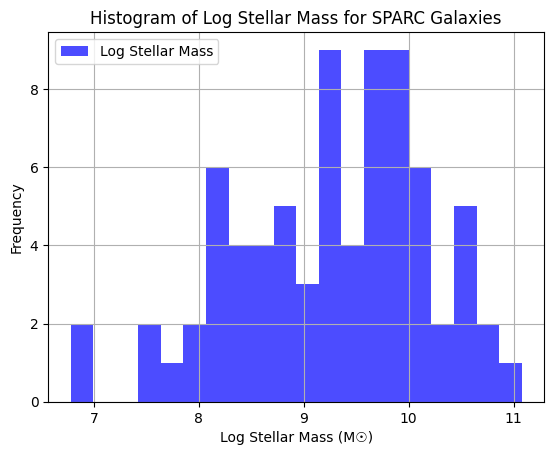

In [4]:
print(len(sparc_logM_star))
plt.hist(sparc_logM_star, bins=20, color='blue', alpha=0.7, label='Log Stellar Mass')
plt.xlabel('Log Stellar Mass (M☉)')
plt.ylabel('Frequency')
plt.title('Histogram of Log Stellar Mass for SPARC Galaxies')
plt.legend()
plt.grid(True)
plt.show()


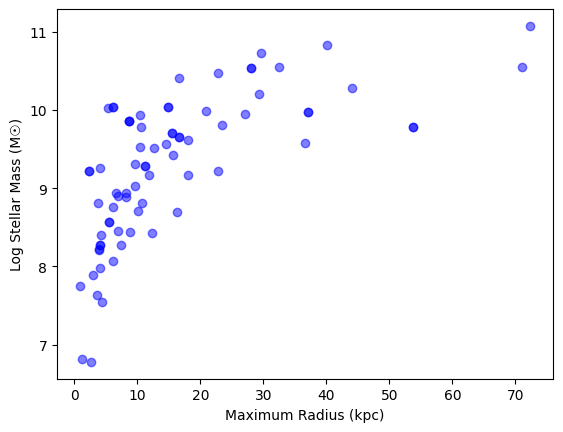

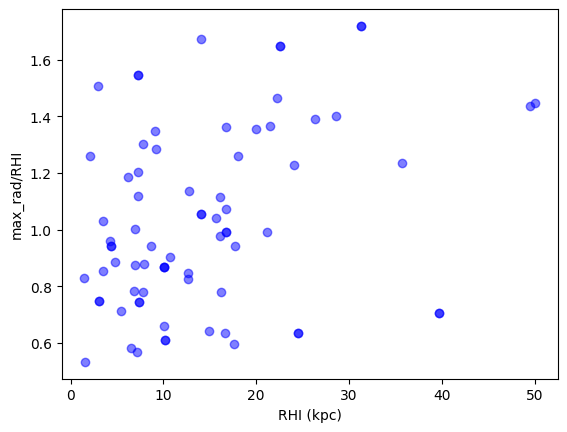

In [5]:
plt.scatter(max_rad_sparc, sparc_logM_star, color='blue', alpha=0.5)
plt.xlabel('Maximum Radius (kpc)')
plt.ylabel('Log Stellar Mass (M☉)')
plt.show()

plt.scatter(RHI, max_rad_sparc/RHI, color='blue', alpha=0.5)
plt.xlabel('RHI (kpc)')
plt.ylabel('max_rad/RHI')
plt.show()

In [6]:
#EXTRACTING STELLAR MASSES FROM TNG
stellar_mass_TNG = []
t_total_mass_TNG = []

for gal in Chosen_gals_TNG:
    stellar_mass_TNG.append(float(gals_dataframe_TNG['stellar_mass'][gal == gals_dataframe_TNG['gal_number']])) 
    t_total_mass_TNG.append(float(gals_dataframe_TNG['T_total_mass'][gal == gals_dataframe_TNG['gal_number']]))

#EXTRACTING STELLAR MASSES FROM NH

stellar_mass_NH = []
t_total_mass_NH = []

for gal in Chosen_gals_NH:
    stellar_mass_NH.append(float(gals_dataframe_NH['mass'][gal == gals_dataframe_NH['Gal_number']]))
    t_total_mass_NH.append(float(gals_dataframe_NH['T_total_mass'][gal == gals_dataframe_NH['Gal_number']]))


/tmp/ipykernel_887563/1843903085.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  stellar_mass_TNG.append(float(gals_dataframe_TNG['stellar_mass'][gal == gals_dataframe_TNG['gal_number']]))
/tmp/ipykernel_887563/1843903085.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_total_mass_TNG.append(float(gals_dataframe_TNG['T_total_mass'][gal == gals_dataframe_TNG['gal_number']]))
/tmp/ipykernel_887563/1843903085.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  stellar_mass_NH.append(float(gals_dataframe_NH['mass'][gal == gals_dataframe_NH['Gal_number']]))
/tmp/ipykernel_887563/1843903085.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeErr

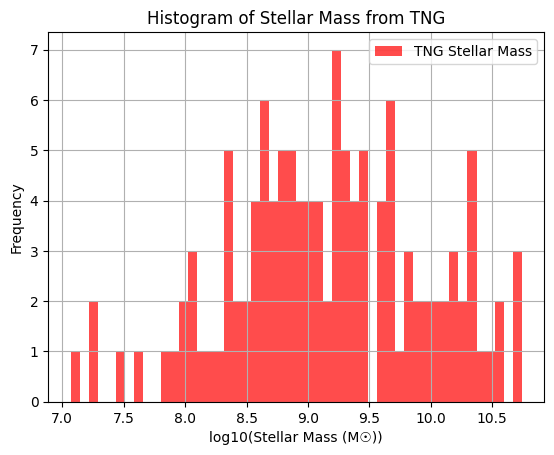

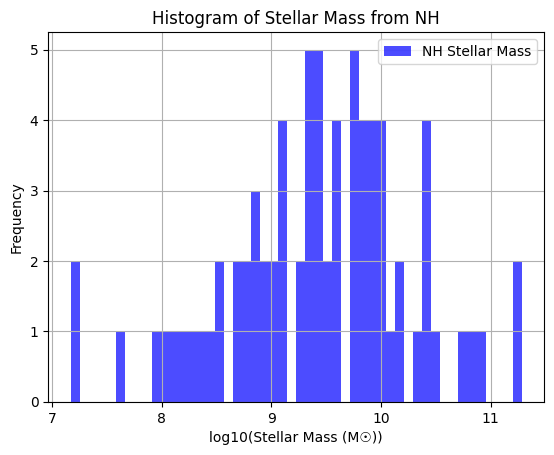

In [7]:
plt.hist(np.log10(stellar_mass_TNG), bins=50, color='red', alpha=0.7, label='TNG Stellar Mass')
plt.xlabel('log10(Stellar Mass (M☉))')
plt.ylabel('Frequency')
plt.title('Histogram of Stellar Mass from TNG')
plt.legend()
plt.grid(True)
plt.show()

plt.hist(np.log10(stellar_mass_NH), bins=50, color='blue', alpha=0.7, label='NH Stellar Mass')
plt.xlabel('log10(Stellar Mass (M☉))')
plt.ylabel('Frequency')
plt.title('Histogram of Stellar Mass from NH')
plt.legend()
plt.grid(True)
plt.show()

6.778151250383644 11.07690872783857


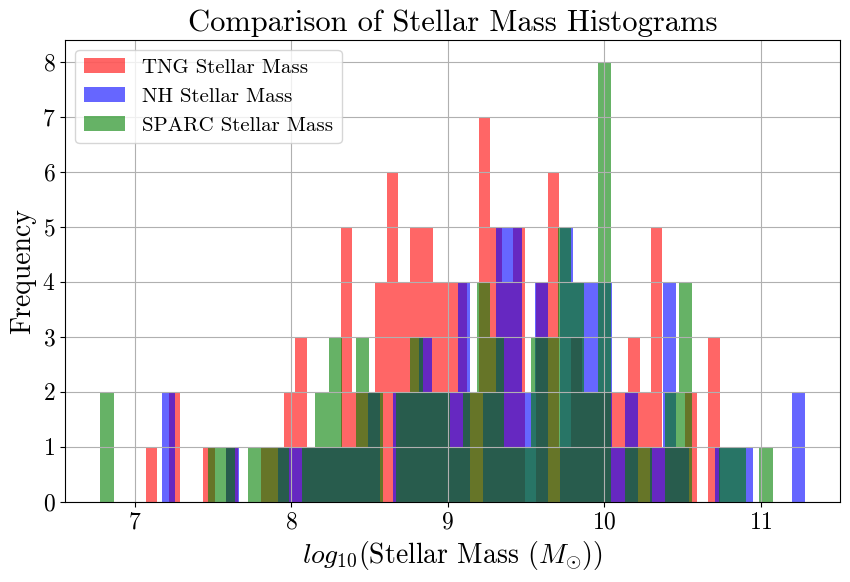

In [8]:

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 17   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 17   # Increase y-axis tick font size

plt.figure(figsize=(10, 6))

plt.hist(np.log10(stellar_mass_TNG), bins=50, color='red', alpha=0.6, label='TNG Stellar Mass')
plt.hist(np.log10(stellar_mass_NH), bins=50, color='blue', alpha=0.6, label='NH Stellar Mass')
plt.hist(sparc_logM_star, bins=50, color='green', alpha=0.6, label='SPARC Stellar Mass')

print(min(sparc_logM_star), max(sparc_logM_star))
plt.xlabel(r'$log_{10}$(Stellar Mass ($M_{\odot}$))', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.title('Comparison of Stellar Mass Histograms', fontsize=22)
plt.legend(frameon=True, fontsize=15)
plt.grid(True)
plt.show()

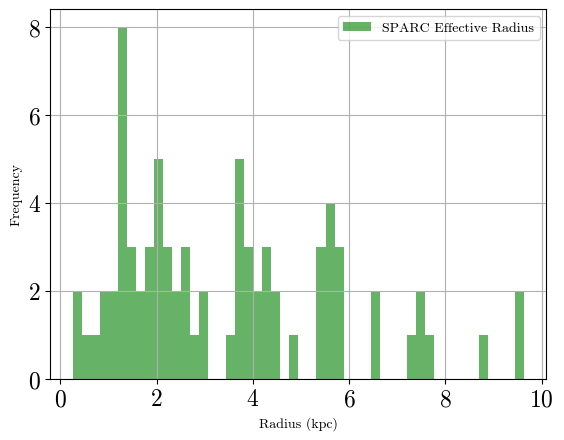

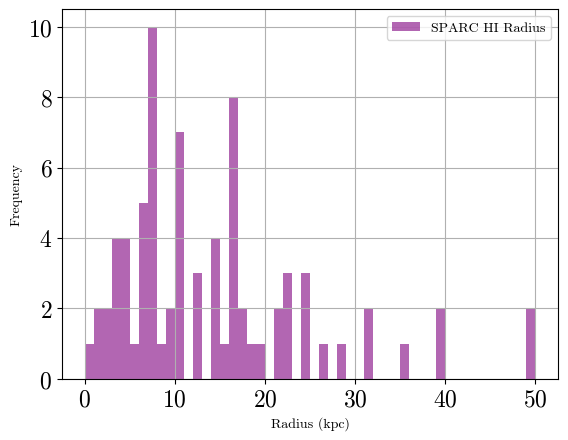

In [9]:
plt.hist(Reff, bins=50, color='green', alpha=0.6, label='SPARC Effective Radius')
plt.xlabel('Radius (kpc)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

plt.hist(RHI, bins=50, color='purple', alpha=0.6, label='SPARC HI Radius')
plt.xlabel('Radius (kpc)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
R_max_TNG = []
R_max_NH = []
no_of_RHI_TNG = 2
no_of_RHI_NH = 2


for gal in Chosen_gals_TNG:

    R_max_TNG.append(no_of_RHI_TNG * gals_dataframe_TNG['gas_r_half'][gal == gals_dataframe_TNG['gal_number']])
    

for gal in Chosen_gals_NH:

    R_max_NH.append(no_of_RHI_NH * gals_dataframe_NH['gas_r_half'][gal == gals_dataframe_NH['Gal_number']])




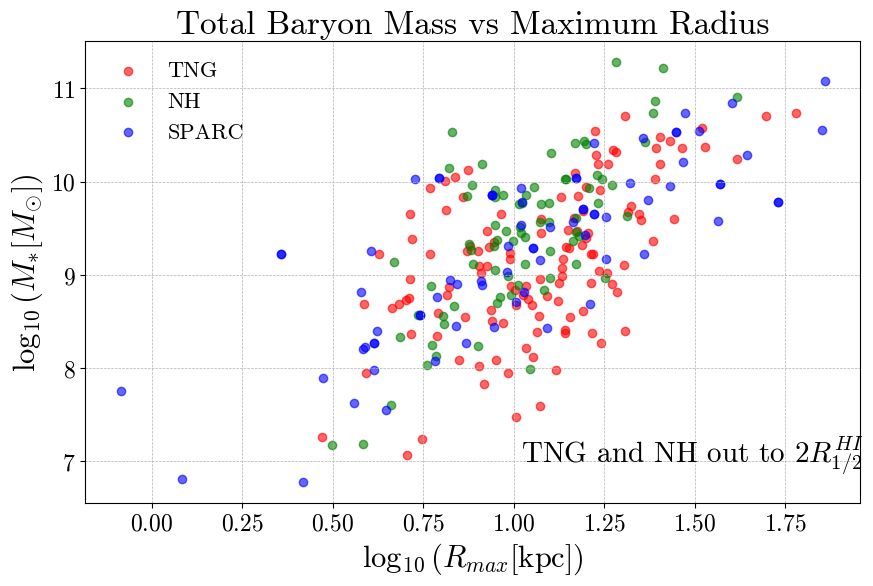

In [11]:

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 17   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 17   # Increase y-axis tick font size

plt.figure(figsize=(10, 6))

plt.scatter(np.log10(R_max_TNG), np.log10(stellar_mass_TNG), color='red', alpha=0.6, label='TNG')
plt.scatter(np.log10(R_max_NH), np.log10(stellar_mass_NH), color='green', alpha=0.6, label='NH')
plt.scatter(np.log10(max_rad_sparc), sparc_logM_star, color='blue', alpha=0.6, label='SPARC')
plt.text(1.02, 7, 'TNG and NH out to ' + str(no_of_RHI_TNG) + '$R_{1/2}^{HI}$', fontsize=21, color='black')
plt.ylabel('$\log_{10}{(M_{*}[M_{\odot}])}$', size=22)
plt.xlabel('$\log_{10}(R_{max}$[kpc])', size=22)
plt.title('Total Baryon Mass vs Maximum Radius', size = 24)
plt.legend(prop ={'size': 16}, frameon = False)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


551    1035
Name: gal_number, dtype: int64
25.376605664648604


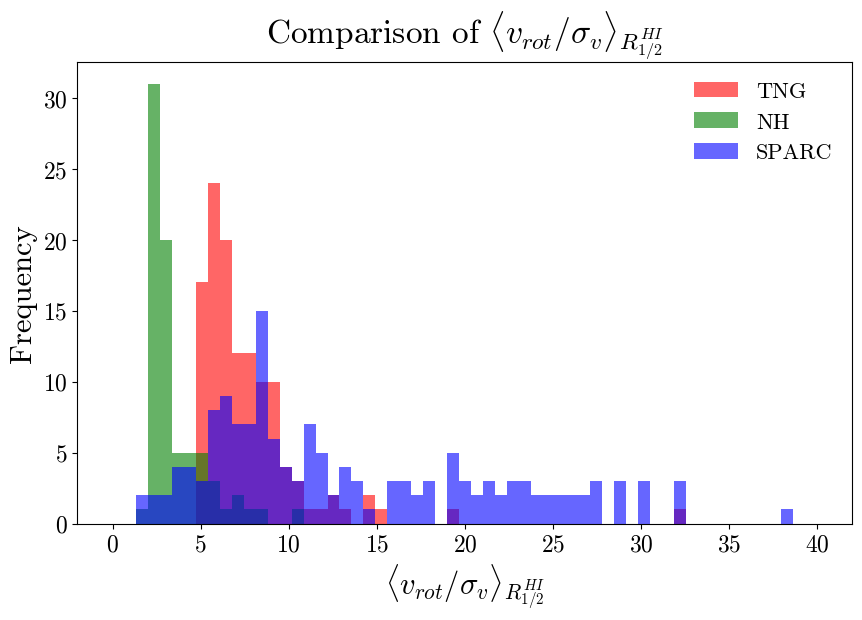

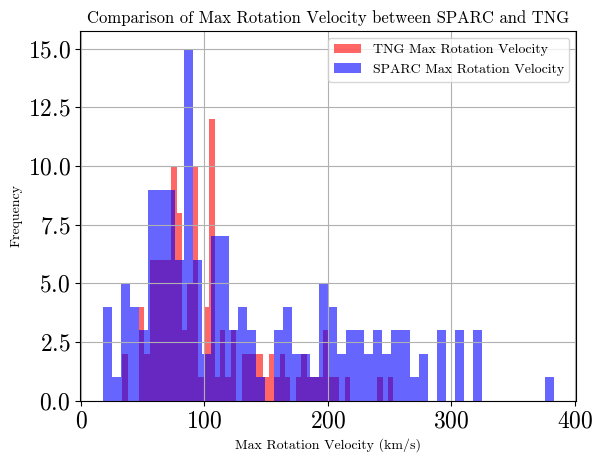

In [12]:
v_rot_over_sigma_v_TNG_csv = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/v_sig_ratios_TNG.csv')

gal_numbers_TNG = v_rot_over_sigma_v_TNG_csv['gal_number']

mask = np.isin(gal_numbers_TNG, Chosen_gals_TNG)

v_rot_over_sigma_v_TNG = v_rot_over_sigma_v_TNG_csv['mean_v_sig_ratio'][mask]

v_rot_TNG = v_rot_over_sigma_v_TNG_csv['max_v_rot'][mask]

v_rot_over_sigma_v_TNG = v_rot_over_sigma_v_TNG[v_rot_over_sigma_v_TNG > 0]

v_rot_TNG = v_rot_TNG[v_rot_TNG > 0]

v_rot_over_sigma_v_NH = pd.read_csv('/mnt/users/darnej/MPhys/v_sig_ratios_NH.csv')

gal_numbers_NH = v_rot_over_sigma_v_NH['gal_number']

print(gal_numbers_NH[v_rot_over_sigma_v_NH['mean_v_sig_ratio'] == max(v_rot_over_sigma_v_NH['mean_v_sig_ratio'])])
print(max(v_rot_over_sigma_v_NH['mean_v_sig_ratio']))

mask = np.isin(gal_numbers_NH, Chosen_gals_NH)

v_rot_over_sigma_v_NH = v_rot_over_sigma_v_NH['mean_v_sig_ratio'][mask]

v_rot_over_sigma_v_NH = v_rot_over_sigma_v_NH[v_rot_over_sigma_v_NH > 0]

V_max = sparc_df['Vmax']  # Maximum rotation velocity in km/s

v_rot_over_sigma_v_SPARC = V_max/10

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 17   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 17   # Increase y-axis tick font size

plt.figure(figsize=(10, 6))

bins = np.linspace(0, 40, 60)

plt.hist(v_rot_over_sigma_v_TNG, bins=bins, color='red', alpha=0.6, label='TNG')
plt.hist(v_rot_over_sigma_v_NH, bins=bins, color='green', alpha=0.6, label='NH')
plt.hist(v_rot_over_sigma_v_SPARC, bins=bins, color='blue', alpha=0.6, label='SPARC')

plt.xlabel(r'$\langle v_{rot}/\sigma_{v}\rangle_{R_{1/2}^{HI}}$', size=22)
plt.ylabel('Frequency', size=22)
plt.title(r'Comparison of $\langle v_{rot}/\sigma_{v}\rangle_{R_{1/2}^{HI}}$', size=24)
plt.legend(prop ={'size': 16}, frameon = False)
plt.show()

plt.hist(v_rot_TNG, bins=50, color='red', alpha=0.6, label='TNG Max Rotation Velocity')
plt.hist(V_max, bins=50, color='blue', alpha=0.6, label='SPARC Max Rotation Velocity')
plt.xlabel('Max Rotation Velocity (km/s)')
plt.ylabel('Frequency')
plt.title('Comparison of Max Rotation Velocity between SPARC and TNG')
plt.legend()
plt.grid(True)
plt.show()


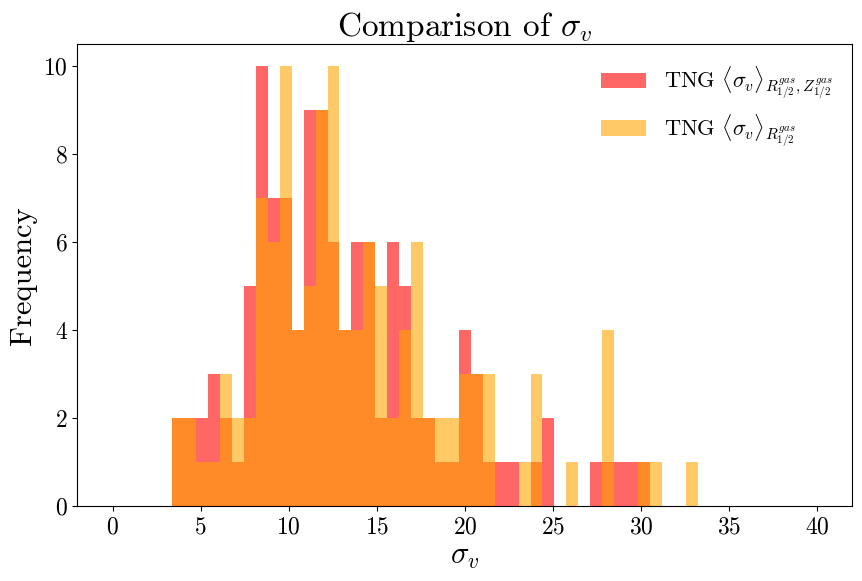

In [21]:
v_rot_over_sigma_v_TNG_csv = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/v_sig_ratios_TNG.csv')

gal_numbers_TNG = v_rot_over_sigma_v_TNG_csv['gal_number']

mask = np.isin(gal_numbers_TNG, Chosen_gals_TNG)

sigma_v_z_TNG = v_rot_over_sigma_v_TNG_csv['mean_sig_v_z'][mask]

sigma_v_TNG = v_rot_over_sigma_v_TNG_csv['mean_sig_v'][mask]

v_rot_over_sigma_v_NH = pd.read_csv('/mnt/users/darnej/MPhys/v_sig_ratios_NH.csv')

gal_numbers_NH = v_rot_over_sigma_v_NH['gal_number']

mask = np.isin(gal_numbers_NH, Chosen_gals_NH)

sigma_v_z_NH = v_rot_over_sigma_v_NH['mean_sig_v_z'][mask]

sigma_v_NH = v_rot_over_sigma_v_NH['mean_sig_v'][mask]


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 17   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 17   # Increase y-axis tick font size

plt.figure(figsize=(10, 6))

bins = np.linspace(0, 40, 60)

plt.hist(sigma_v_z_TNG, bins=bins, color='red', alpha=0.6, label=r'TNG $\langle\sigma_v\rangle_{R_{1/2}^{gas}, Z_{1/2}^{gas}}$')
#plt.hist(sigma_v_z_NH, bins=bins, color='green', alpha=0.6, label=r'NH $\langle\sigma_v\rangle_{R_{1/2}^{gas}, Z_{1/2}^{gas}}$')
plt.hist(sigma_v_TNG, bins=bins, color='orange', alpha=0.6, label=r'TNG $\langle\sigma_v\rangle_{R_{1/2}^{gas}}$')
#plt.hist(sigma_v_NH, bins=bins, color='purple', alpha=0.6, label=r'NH $\langle\sigma_v\rangle_{R_{1/2}^{gas}}$')


plt.xlabel(r'$\sigma_v$', size=22)
plt.ylabel('Frequency', size=22)
plt.title(r'Comparison of $\sigma_v$', size=24)
plt.legend(prop ={'size': 16}, frameon = False)
plt.show()




122


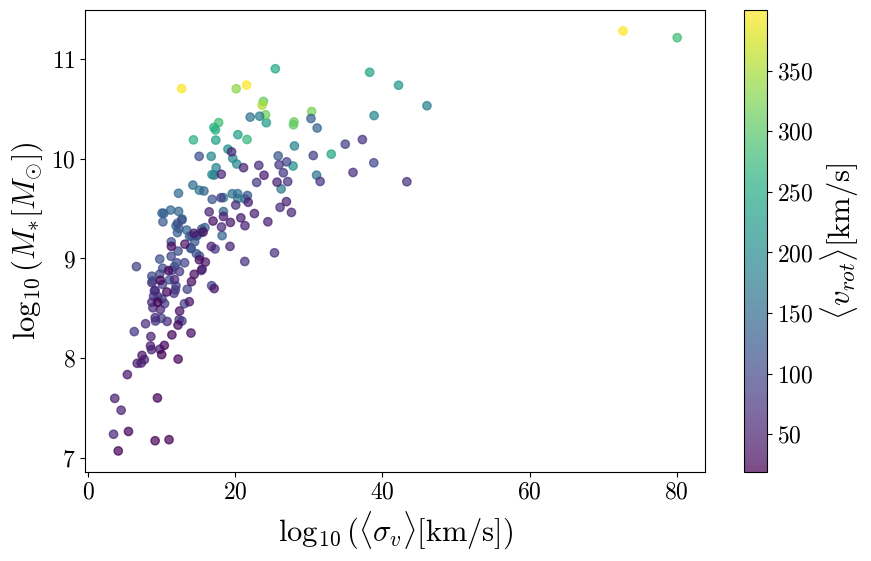

In [13]:
y_TNG = stellar_mass_TNG

gal_numbers_TNG = v_rot_over_sigma_v_TNG_csv['gal_number']

mask = np.isin(gal_numbers_TNG, Chosen_gals_TNG)

sigma_v_TNG = v_rot_over_sigma_v_TNG_csv['mean_sig_v'][mask]

x_TNG = sigma_v_TNG

print(len(x_TNG))

c_TNG = max_v_rot = v_rot_over_sigma_v_TNG_csv['mean_v_rot'][mask]

y_NH = stellar_mass_NH

v_rot_over_sigma_v_NH = pd.read_csv('/mnt/users/darnej/MPhys/v_sig_ratios_NH.csv')

gal_numbers_NH = v_rot_over_sigma_v_NH['gal_number']

mask = np.isin(gal_numbers_NH, Chosen_gals_NH)

sigma_v_NH = v_rot_over_sigma_v_NH['mean_sig_v'][mask]

x_NH = sigma_v_NH

c_NH = v_rot_over_sigma_v_NH['mean_v_rot'][mask]


plt.figure(figsize=(10, 6))

scatter = plt.scatter(x_TNG, np.log10(y_TNG), c=c_TNG, cmap='viridis', alpha=0.7)
scatter = plt.scatter(x_NH, np.log10(y_NH), c=c_NH, cmap='viridis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$\langle v_{rot}\rangle$[km/s]', size=22)
plt.ylabel(r'$\log_{10}(M_{*}[M_{\odot}])$', size=22)
plt.xlabel(r'$\log_{10}(\langle\sigma_{v}\rangle$[km/s])', size=22)
plt.show()




In [14]:
mean_sig_v = list(x_NH) + list(x_TNG)

gals = list(Chosen_gals_NH) + list(Chosen_gals_TNG)

mean_sig_v_mapping = np.argsort(mean_sig_v)

mean_sig_v_sorted = np.array(mean_sig_v)[mean_sig_v_mapping]

gals_sorted = np.array(gals)[mean_sig_v_mapping]

print(mean_sig_v_sorted[-10:])
print(gals_sorted[-10:])

gals_sorted_TNG = gals_sorted[gals_sorted > 1080]
print(gals_sorted_TNG[-5:])


[36.01603859 37.28996146 38.27695203 38.84063703 38.880526   42.19945661
 43.33225737 46.06223656 72.70543141 80.06176315]
[8.900e+01 5.700e+01 7.000e+00 1.080e+02 1.100e+01 1.000e+00 2.200e+01
 2.300e+01 9.000e+00 1.045e+03]
[555013. 220601. 537488. 220603. 605054.]


In [15]:
#[1045, 9, 38, 220597, 547844]

122


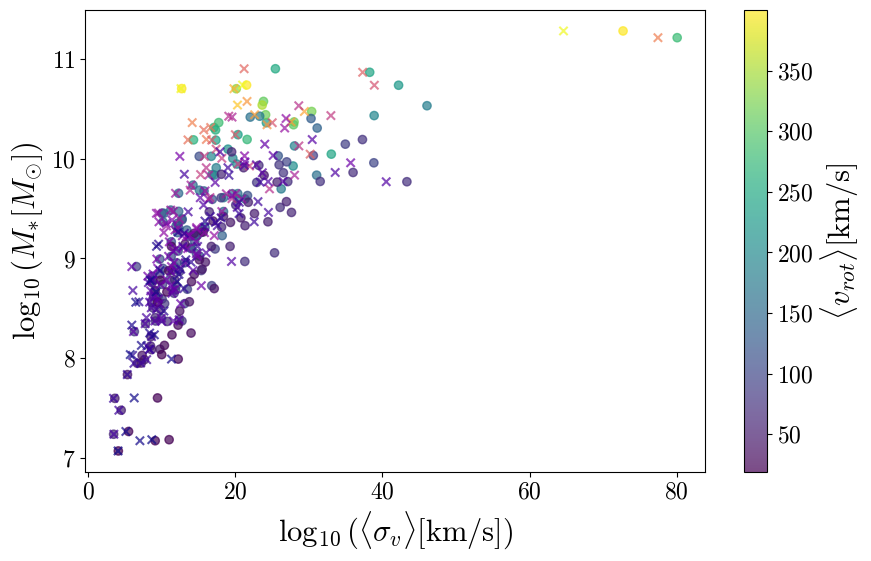

In [16]:
y_TNG = stellar_mass_TNG

gal_numbers_TNG = v_rot_over_sigma_v_TNG_csv['gal_number']

mask = np.isin(gal_numbers_TNG, Chosen_gals_TNG)

sigma_v_TNG = v_rot_over_sigma_v_TNG_csv['mean_sig_v'][mask]

sigma_v_z_TNG = v_rot_over_sigma_v_TNG_csv['mean_sig_v_z'][mask]

x_TNG = sigma_v_TNG

print(len(x_TNG))

c_TNG = max_v_rot = v_rot_over_sigma_v_TNG_csv['mean_v_rot'][mask]

y_NH = stellar_mass_NH

v_rot_over_sigma_v_NH = pd.read_csv('/mnt/users/darnej/MPhys/v_sig_ratios_NH.csv')

gal_numbers_NH = v_rot_over_sigma_v_NH['gal_number']

mask = np.isin(gal_numbers_NH, Chosen_gals_NH)

sigma_v_NH = v_rot_over_sigma_v_NH['mean_sig_v'][mask]

sigma_v_z_NH = v_rot_over_sigma_v_NH['mean_sig_v_z'][mask]

x_NH = sigma_v_NH

c_NH = v_rot_over_sigma_v_NH['mean_v_rot'][mask]


plt.figure(figsize=(10, 6))

scatter = plt.scatter(x_TNG, np.log10(y_TNG), c=c_TNG, cmap='viridis', alpha=0.7)
scatter = plt.scatter(x_NH, np.log10(y_NH), c=c_NH, cmap='viridis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$\langle v_{rot}\rangle$[km/s]', size=22)

scatter = plt.scatter(sigma_v_z_TNG, np.log10(y_TNG), c=c_TNG, cmap='plasma', alpha=0.7, marker='x')
scatter = plt.scatter(sigma_v_z_NH, np.log10(y_NH), c=c_NH, cmap='plasma', alpha=0.7, marker='x')

x_span = x_TNG - sigma_v_z_TNG
y_span = np.log10(y_TNG) - np.log10(y_TNG)

plt.plot()


plt.ylabel(r'$\log_{10}(M_{*}[M_{\odot}])$', size=22)
plt.xlabel(r'$\log_{10}(\langle\sigma_{v}\rangle$[km/s])', size=22)
plt.show()


